# Install Python packages and download dataset

# Import Python Modules

In [ ]:
from data_process import prepare, read_image

import os
from PIL import Image
from mat73 import loadmat

import tensorflow as tf
import tensorflow.keras as keras
from keras.callbacks import CSVLogger
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# to perform subject-wise cross validation
from sklearn.model_selection import GroupKFold,StratifiedGroupKFold, train_test_split
import cv2

In [31]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## Load images, masks and labels

In [32]:
labels = np.load('./dataset/labels.npy')
images = np.load('./dataset/images.npy', mmap_mode='r')
masks = np.load('./dataset/masks.npy', mmap_mode='r')
patient_ids = np.load('./dataset/patient_ids.npy').flatten()
file_paths = np.load('./dataset/file_paths.npy')
integer_to_class = {'1': 'meningioma (1)', '2': 'glioma (2)', '3': 'pituitary tumor (3)'}
file_paths, file_paths_test, labels, labels_test, patient_ids, patient_ids_test = train_test_split(file_paths, labels, patient_ids, test_size=0.2, random_state=42)

# Create dataset splits




## One test

To test our implementation quickly we used the following split, without considering patient IDs: 60% of examples are placed in the training dataset, 20% are placed in the validation dataset, and the remaining 20% are used for the test set.

In [33]:
X_train, X_val, y_train, y_val = train_test_split(file_paths, labels, test_size=0.25, random_state=1)


train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((file_paths_test, labels_test))

## Report on balance of classes in each of the datasets

In [34]:

def summarize_dataset(ds, name):
    num_classes = 3
    count = np.zeros(num_classes, dtype=np.int32)
    for _, label in ds:
      count[label.numpy() - 1] += 1

    total = np.sum(count)

    label_stats = ""

    for (id_, label) in integer_to_class.items():
      label_stats += "{} {}\n".format(integer_to_class[id_], count[int(id_) - 1])

    print(f"Distribution of labels for {name}")
    print(label_stats)
    return

if train_ds is not None:
  summarize_dataset(train_ds, "Training Dataset")
  summarize_dataset(val_ds, "Validation Dataset")
  summarize_dataset(test_ds, "Test Dataset")

Distribution of labels for Training Dataset
meningioma (1) 408
glioma (2) 856
pituitary tumor (3) 574

Distribution of labels for Validation Dataset
meningioma (1) 144
glioma (2) 289
pituitary tumor (3) 180

Distribution of labels for Test Dataset
meningioma (1) 156
glioma (2) 281
pituitary tumor (3) 176



## Data Preprocessing

* Resize every image to 256 $\times$ 256 pixels.
* Load the dataset in batches of 32 images so that batches can be stored on GPU memory.
* Scalar-valued targets should be converted to one-hot vectors.

In [35]:
train_ds = prepare(train_ds, shuffle=True, augment=True)
val_ds = prepare(val_ds, shuffle=True, augment=False)
test_ds = prepare(test_ds, shuffle=True, augment=False)

In [36]:
resize = keras.Sequential([
keras.layers.Resizing(256, 256)
])


normalize = keras.layers.Normalization(axis=(1, 2))
adapt_data = train_ds.map(lambda x, y: resize(x))
normalize.adapt(adapt_data)

# Model Implementation

In [41]:
model = keras.Sequential()
model.name = "classifier_to_explain"

### Pre-Processing Layer ###
model.add(keras.Input(shape=(512, 512, 1)))
model.add(keras.layers.Resizing(256, 256))
model.add(normalize)

### Classification Blocks ###

model.add(keras.layers.Conv2D(16, kernel_size=(5, 5), strides=(2, 2), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Conv2D(32, kernel_size=(3, 3), strides=(2, 2), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Conv2D(64, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Conv2D(128, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
model.add(keras.layers.Dropout(0.5))

# Flattening output
model.add(keras.layers.Flatten())

# Layer 18, 19 - Fully Connected, ReLU
model.add(keras.layers.Dense(2048, activation='relu'))
model.add(keras.layers.Dropout(0.5))

# Layer 20, 21 - Fully Connected, Softmax
model.add(keras.layers.Dense(units=3, activation='softmax'))

model.summary()

Model: "classifier_to_explain"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_17 (Resizing)          │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_10                │ (None, 256, 256, 1)    │       131,073 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,431,428 (16.90 MB)

 Trainable params: 4,300,131 (16.40 MB)

 Non-trainable params: 131,297 (512.88 KB)

In [42]:
# Define a callback to save the model with the lowest validation loss
def train_once(model, train_ds, val_ds, epochs=100, trial_id=0):

  csv_logger = CSVLogger(f'log/log-trial-{trial_id}.csv', append=True, separator=',')
  output_directory = os.getcwd() + "/saved_models"
  model_filename = f"best_model-trial-{trial_id}.keras"
  model_path = os.path.join(output_directory, model_filename)

  model_checkpoint = keras.callbacks.ModelCheckpoint(model_path,
                                                    save_best_only=True,
                                                    save_weights_only=False,
                                                    monitor="val_loss",
                                                    mode="min", verbose=1)


  # Adapt the normalization layer of the model
  model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0), loss='categorical_crossentropy', metrics=['accuracy', 'auc', 'precision', 'recall'])

  # Define a callback for early stopping
  early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=11,
                                                mode="min", verbose=1 if epochs % 10 == 0 else 0)

  # Training configuration
  epochs = 100  # You can adjust the number of epochs

  # Train the model with callbacks
  history = model.fit(
      x=train_ds,  # Provide the input data directly from the dataset
      epochs=epochs,
      validation_data=val_ds,
      callbacks=[model_checkpoint, early_stopping, csv_logger]
  )

  return history



## Training: One-Test

In [39]:
history = train_once(model, train_ds, val_ds)
print(history)

Epoch 1/100

Epoch 1: val_loss improved from inf to 1.63883, saving model to /home/worathur/Documents/CV-Capstone/saved_models/best_model-trial-0.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - accuracy: 0.6052 - auc: 0.7759 - loss: 2.3077 - precision: 0.6191 - recall: 0.5774 - val_accuracy: 0.3181 - val_auc: 0.5437 - val_loss: 1.6388 - val_precision: 0.3232 - val_recall: 0.3116
Epoch 2/100

Epoch 2: val_loss improved from 1.63883 to 1.36157, saving model to /home/worathur/Documents/CV-Capstone/saved_models/best_model-trial-0.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.7269 - auc: 0.8880 - loss: 0.6864 - precision: 0.7537 - recall: 0.6895 - val_accuracy: 0.4225 - val_auc: 0.6372 - val_loss: 1.3616 - val_precision: 0.4430 - val_recall: 0.3997
Epoch 3/100

Epoch 3: val_loss improved from 1.36157 to 1.00636, saving model to /home/worathur/Documents/CV-Capstone/saved_models/best_model-trial-0.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.7794 - auc: 0

KeyboardInterrupt: 

In [12]:
best_train_acc = max(history.history['accuracy'])
best_valid_acc = max(history.history['val_accuracy'])

print(f"Best Training Accuracy: {best_train_acc}")
print(f"Best Validation Accuracy: {best_valid_acc}")

metrics = model.evaluate(x=test_ds, return_dict=True)
test_accuracy = metrics['accuracy']

print(f"Final Test Accuracy: {test_accuracy}")

Best Training Accuracy: 1.0
Best Validation Accuracy: 0.9119086265563965
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8860 - auc: 0.9738 - loss: 0.3814 - precision: 0.8866 - recall: 0.8853  
Final Test Accuracy: 0.8923327922821045


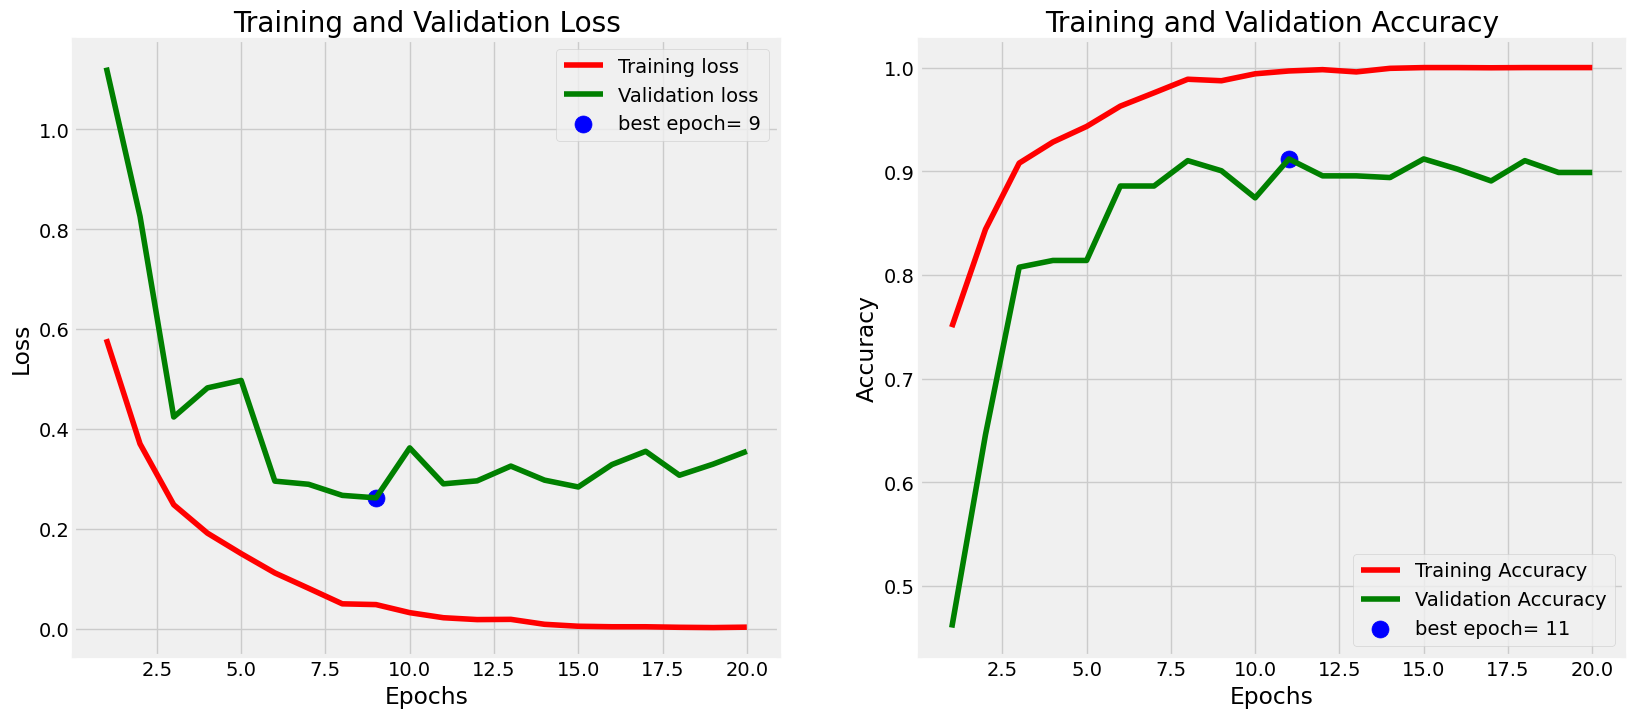

In [13]:
# # Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

## Subject-Wise Cross Validation


With subject-wise cross validation, we ensure that a patient's scans do not appear in both the training and test sets. We split the dataset into **folds**,
where each fold has roughly the same number of unique patients. The function
`assign_folds_custom` picks six folds for training, 2 for validation, and 2 for testing. `assign_folds_custom` is designed to be called in a loop, to return a new (train_set, valid_set, test_set) combination on each iteration.

In [ ]:
# Each patient is limited to appearing in one fold. The number of distinct
# patients in each fold is approximately the same

group_kfold = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
avg_accuracy = 0
n_trials = 0

for i, (train_indices, val_indices) in enumerate(group_kfold.split(file_paths, labels, patient_ids)):
  print(f"=== Trial {i + 1} ===")

  print(f"Fold {i+1} class distribution:", Counter(np.array(labels)[train_indices]))
  print(f"Fold {i+1} class distribution:", Counter(np.array(labels)[val_indices]))

  print(f'Train dataset size: {len(train_indices)}')
  print(f'Validation dataset size: {len(val_indices)}')

  train_ds = tf.data.Dataset.from_tensor_slices((file_paths[train_indices], labels[train_indices]))
    
  val_ds = tf.data.Dataset.from_tensor_slices((file_paths[val_indices], labels[val_indices]))

  train_ds = prepare(train_ds, shuffle=True, augment=True)
  val_ds = prepare(val_ds, shuffle=True, augment=False)

  resize = keras.Sequential([
    keras.layers.Resizing(256, 256)
  ])
  normalize = keras.layers.Normalization(axis=(1, 2))
  adapt_data = train_ds.map(lambda x, y: resize(x))
  normalize.adapt(adapt_data)

  
  model.layers[2] = normalize

  history = train_once(model, train_ds, val_ds, epochs=35, trial_id=i + 1)

  best_train_acc = max(history.history['accuracy'])
  best_valid_acc = max(history.history['val_accuracy'])


  print(f"Best Training Accuracy: {best_train_acc}")
  print(f"Best Validation Accuracy: {best_valid_acc}")

  metrics = model.evaluate(x=test_ds, return_dict=True)
  test_accuracy = metrics['accuracy']

  print(f"Final Test Accuracy: {test_accuracy}")
  avg_accuracy += test_accuracy
  n_trials += 1

print(f"Average Test Accuracy: {avg_accuracy / n_trials}")

=== Trial 1 ===
Fold 1 class distribution: Counter({2: 695, 3: 503, 1: 416})
Fold 1 class distribution: Counter({2: 450, 3: 251, 1: 136})
Train dataset size: 1614
Validation dataset size: 837
Epoch 1/100

Epoch 1: val_loss improved from inf to 1.48998, saving model to /home/worathur/Documents/CV-Capstone/saved_models/best_model-trial-1.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.8549 - auc: 0.9659 - loss: 0.3621 - precision: 0.8646 - recall: 0.8472 - val_accuracy: 0.1673 - val_auc: 0.4388 - val_loss: 1.4900 - val_precision: 0.1673 - val_recall: 0.1673
Epoch 2/100

Epoch 2: val_loss did not improve from 1.48998
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.8655 - auc: 0.9659 - loss: 0.3605 - precision: 0.8712 - recall: 0.8537 - val_accuracy: 0.1673 - val_auc: 0.3181 - val_loss: 1.8833 - val_precision: 0.1673 - val_recall: 0.1673
Epoch 3/100

Epoch 3: val_loss did not improve from 1.48998
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.8421 - auc: 0

In [27]:
print(len(set(patient_ids)))

230
